In [ ]:
# Airline data analysis 
print("Airline EDA - Data clean")

In [3]:
import pandas as pd

In [ ]:
# Check files in the folder

import os

print(os.listdir(r"C:\Users\A GOUUTHAM\Desktop\Flight price project"))



In [4]:
# Read CSV into pandas Data frame
df = pd.read_csv(r"C:\Users\A GOUUTHAM\Desktop\Flight price project\airlines_flights_data.csv")

In [ ]:
print(df.head(5))

In [ ]:
# Check nulls in data:
df.isnull().sum()

In [ ]:
# Check summary stats:
df.describe()

In [ ]:
# Check column names & data types
df.info()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

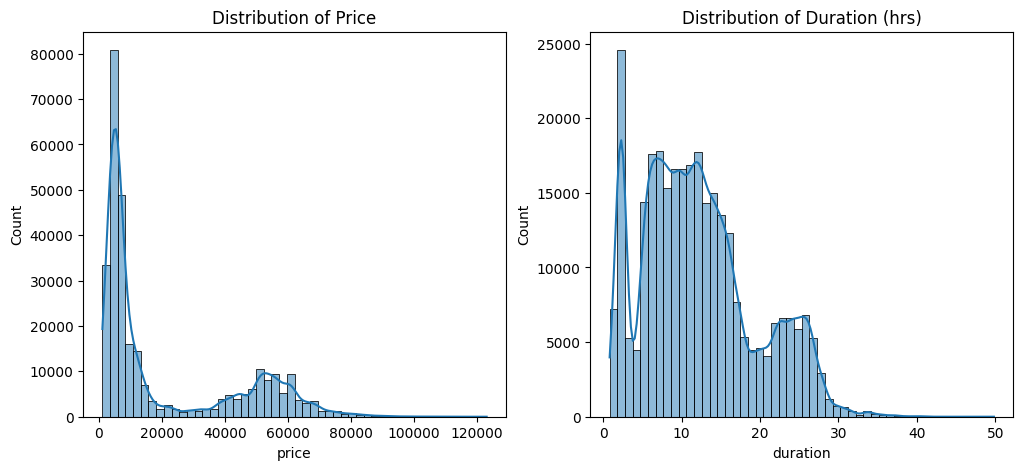

In [16]:
#1 Histogram from price and duration
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of Price")

plt.subplot(1,2,2)
sns.histplot(df['duration'], bins=50, kde=True)
plt.title("Distribution of Duration (hrs)")
plt.show()

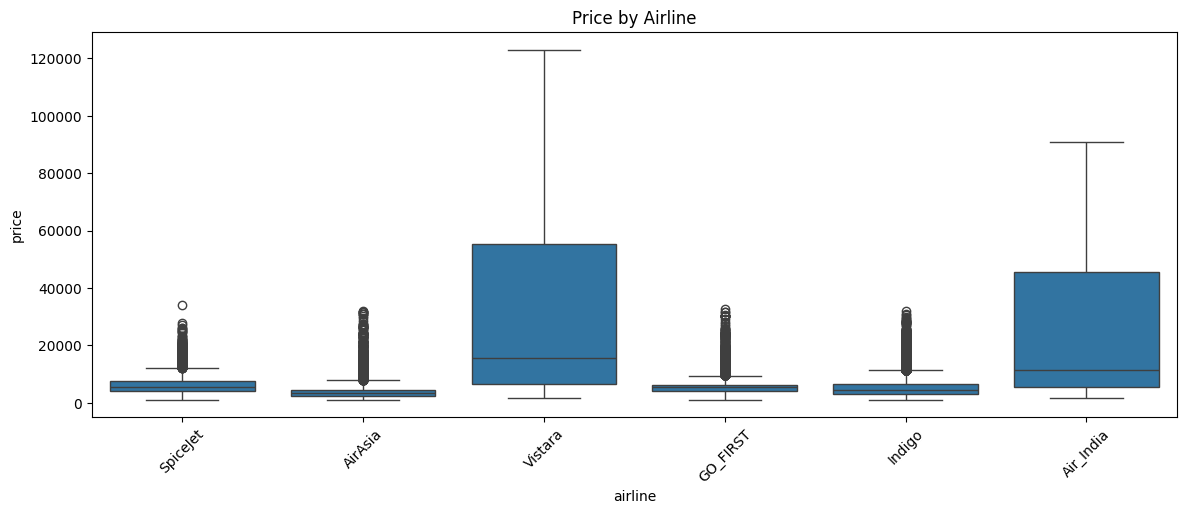

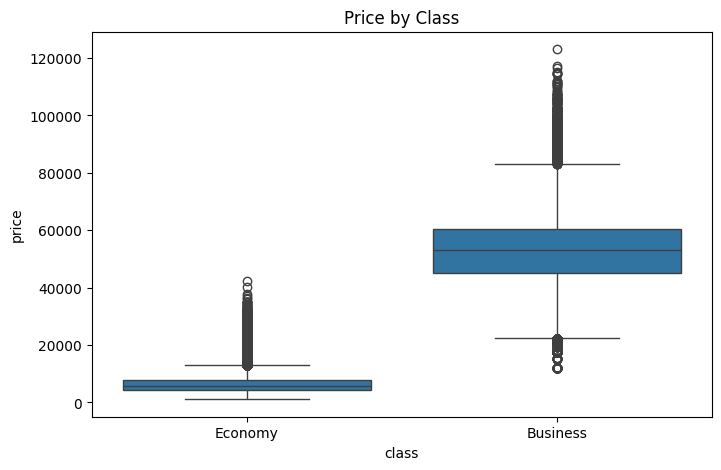

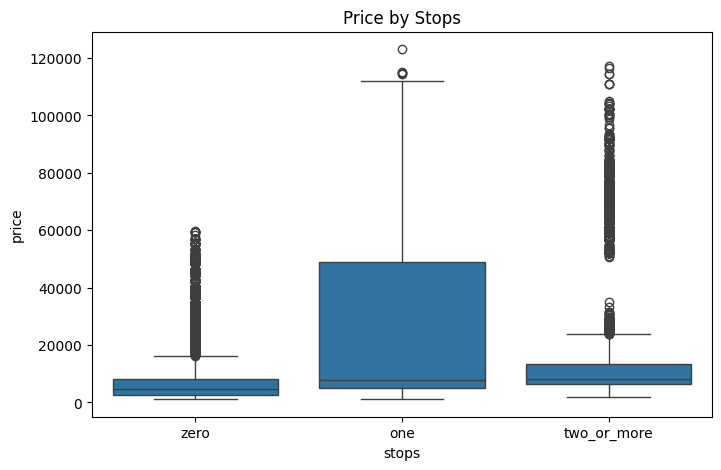

In [17]:
# 2. Boxplots: price by airline, class, stops
plt.figure(figsize=(14,5))
sns.boxplot(x="airline", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Price by Airline")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="class", y="price", data=df)
plt.title("Price by Class")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="stops", y="price", data=df)
plt.title("Price by Stops")
plt.show()

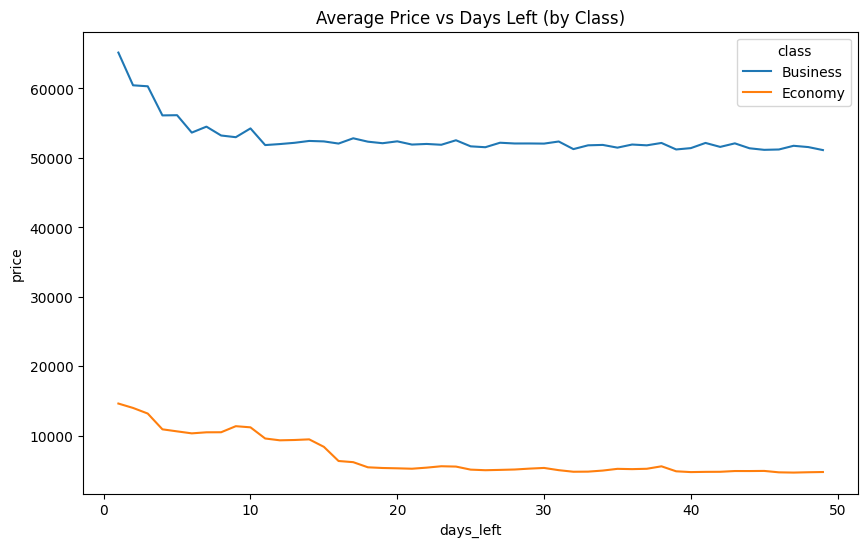

In [18]:
# 3. Line plot: avg price vs days_left (by class)
avg_days_class = df.groupby(["days_left","class"])['price'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(x="days_left", y="price", hue="class", data=avg_days_class)
plt.title("Average Price vs Days Left (by Class)")
plt.show()

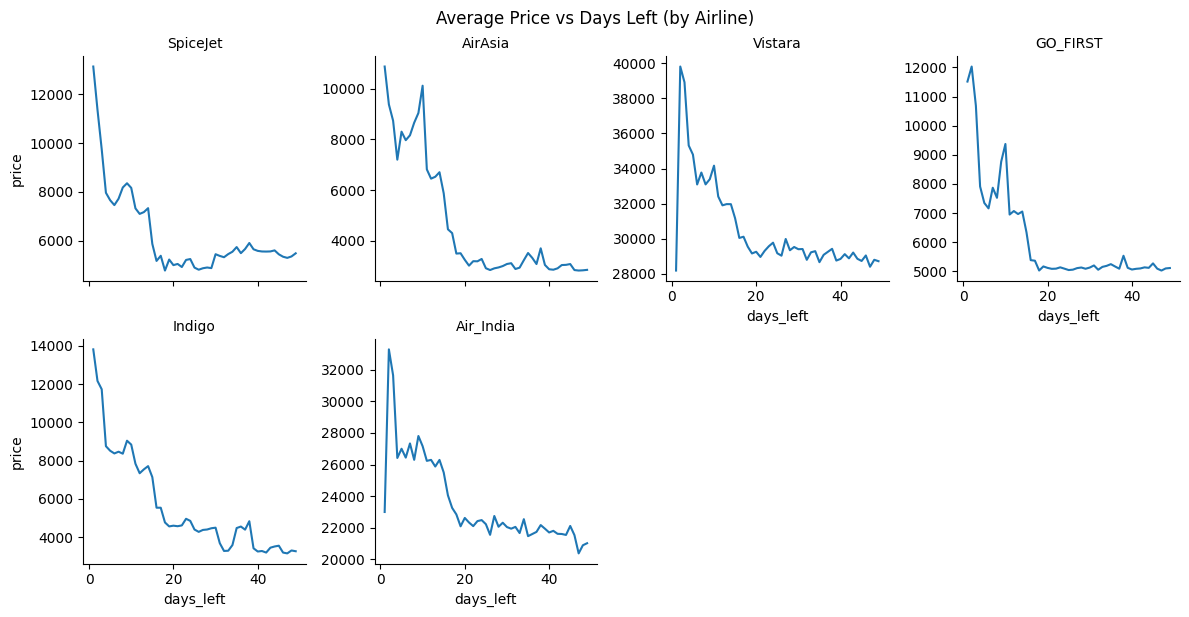

In [19]:
# 4. Line plot: avg price vs days_left (by airline) - small multiples
g = sns.FacetGrid(df, col="airline", col_wrap=4, height=3, sharey=False)
g.map_dataframe(
    sns.lineplot, x="days_left", y="price", estimator="mean", errorbar=None
)
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Average Price vs Days Left (by Airline)", y=1.02)
plt.show()

In [ ]:
#Exploratory data analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10,6)

In [6]:
# Basic info
print("Shape:", df.shape)
df.head()

Shape: (300153, 12)


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [7]:
# Check datatypes and missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [8]:
# Summary statistics
df.describe(include="all")

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153.000000,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,NaN,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,NaN,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,NaN,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,86646.852011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,75038.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,225114.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


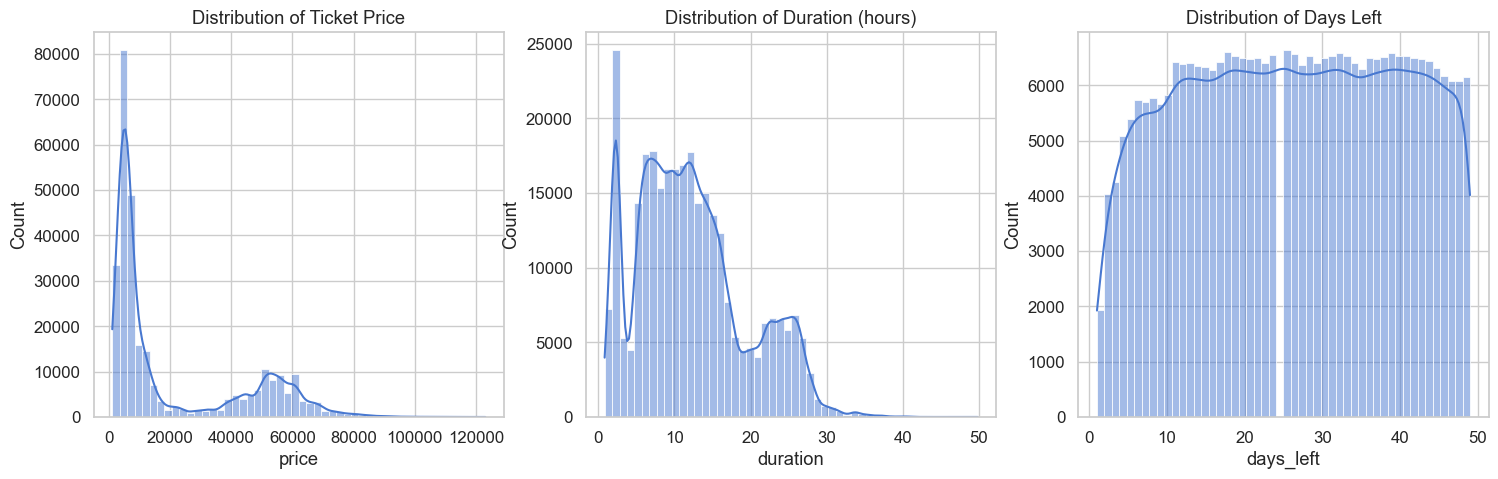

In [9]:
# Distribution of numerical variables
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.histplot(df['price'], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Distribution of Ticket Price")

sns.histplot(df['duration'], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Distribution of Duration (hours)")

sns.histplot(df['days_left'], bins=50, ax=axes[2], kde=True)
axes[2].set_title("Distribution of Days Left")

plt.show()

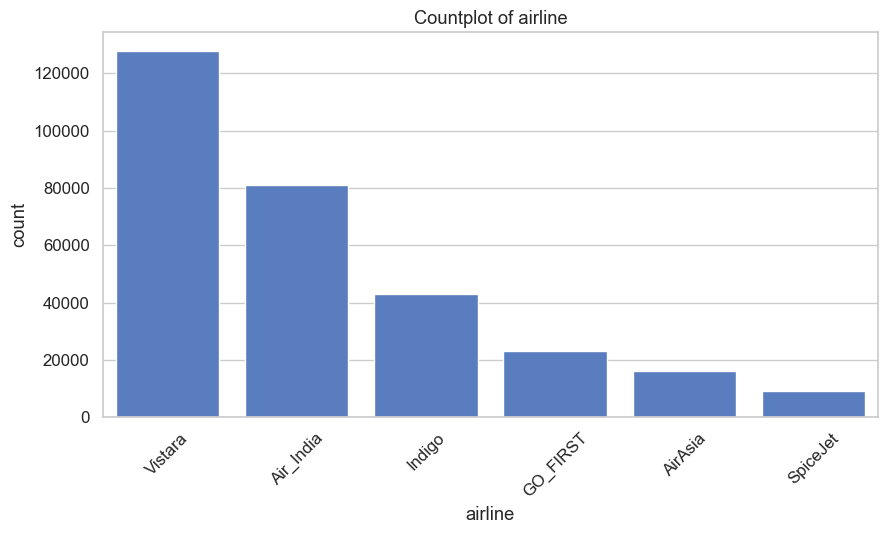

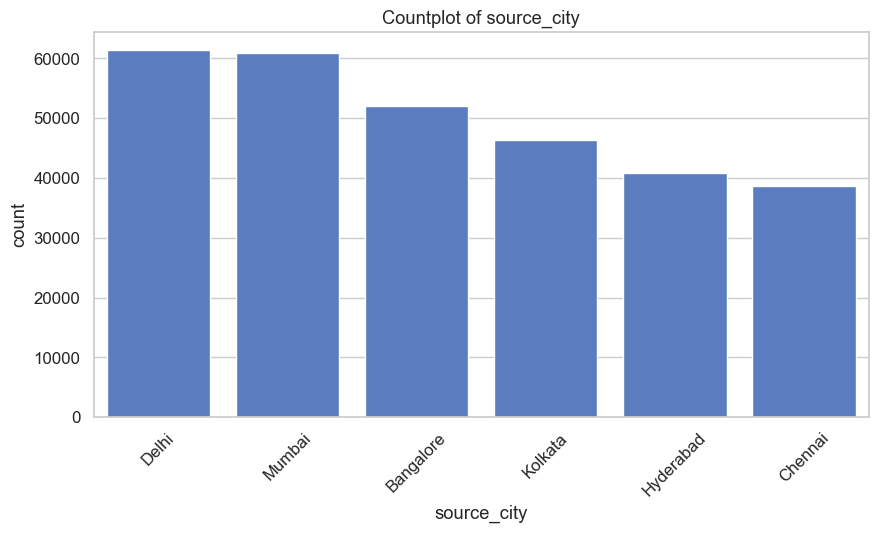

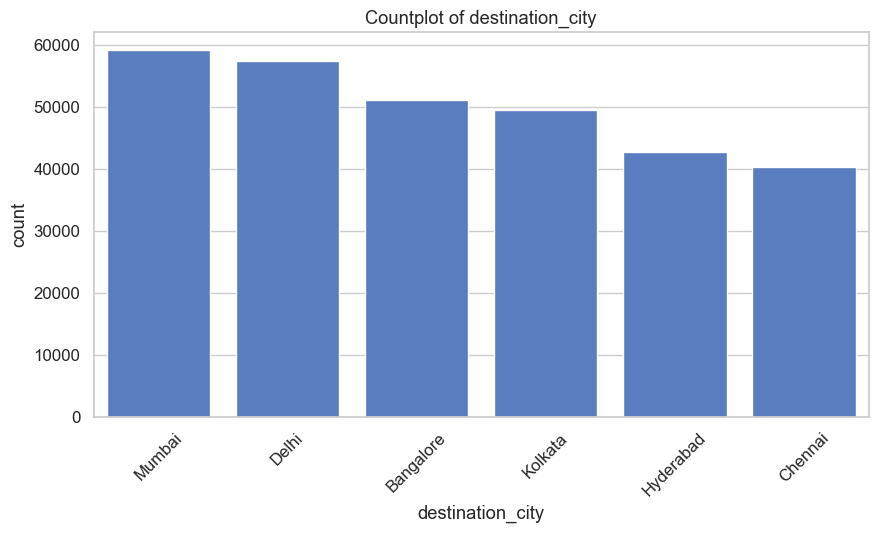

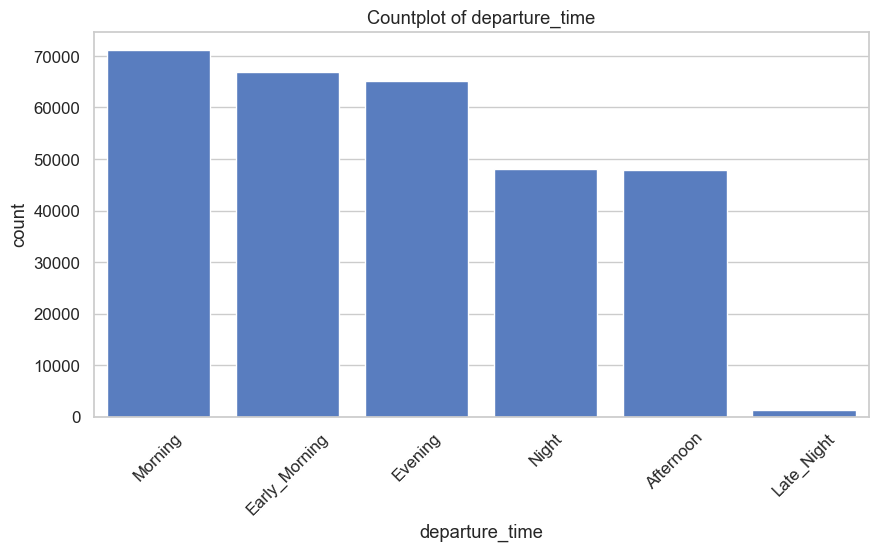

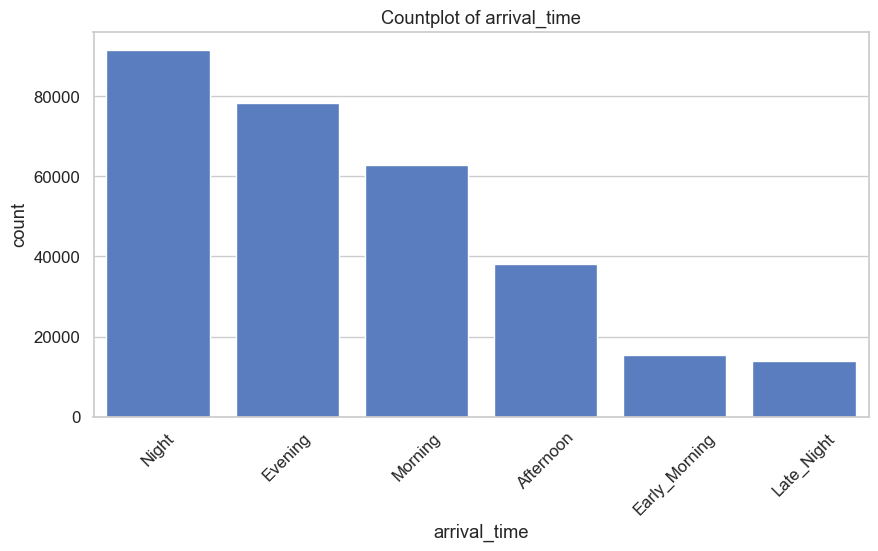

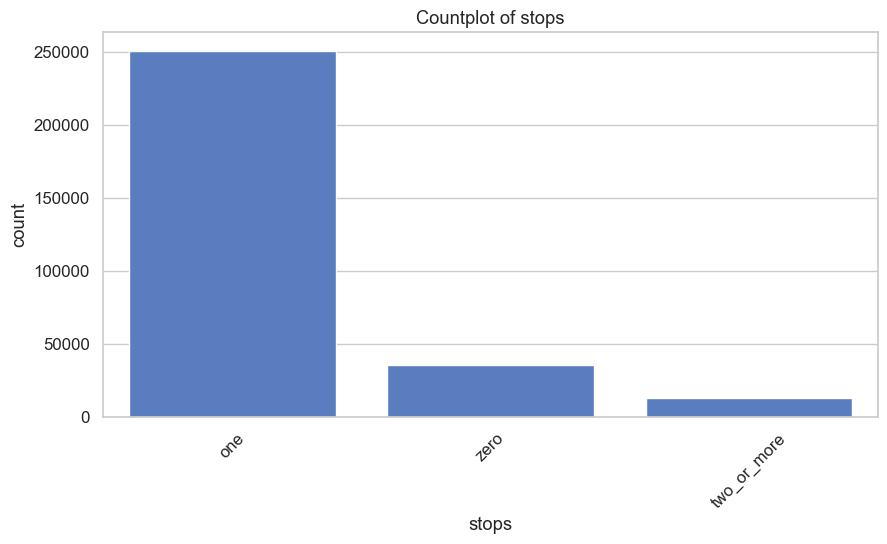

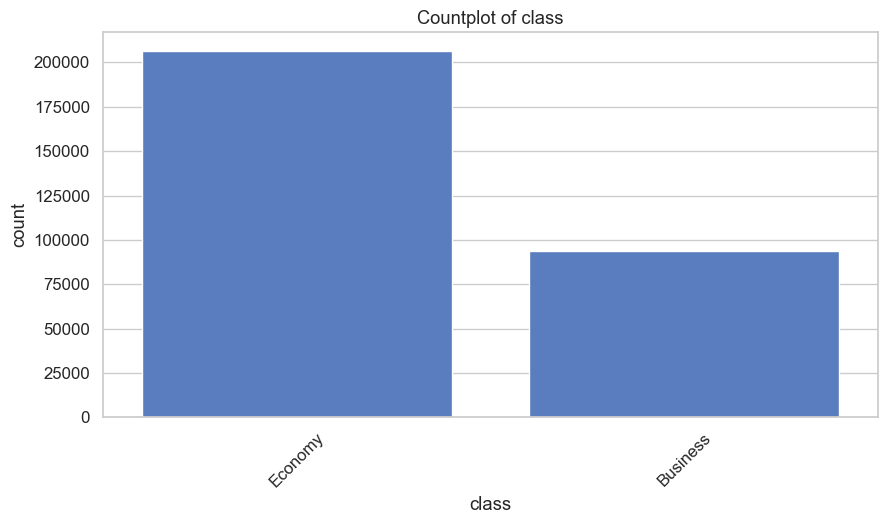

In [10]:
# Countplots for categorical variables
categorical_cols = ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time', 'stops', 'class']

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

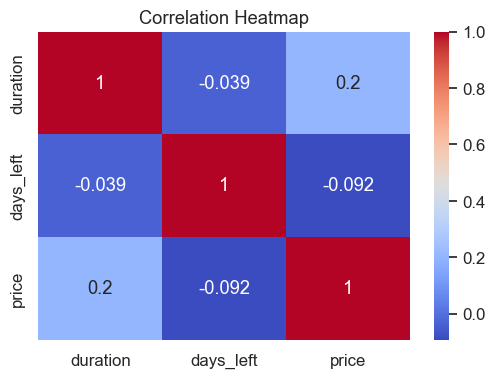

In [11]:
# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['duration', 'days_left', 'price']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

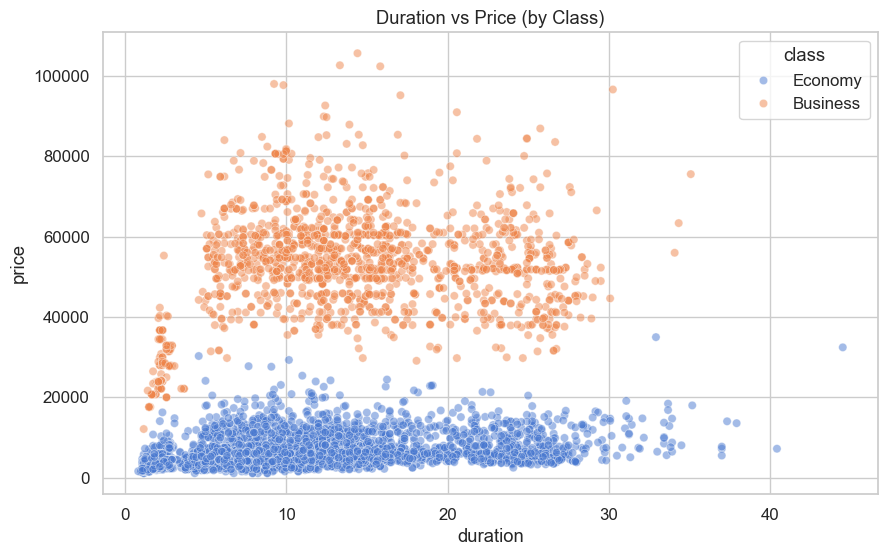

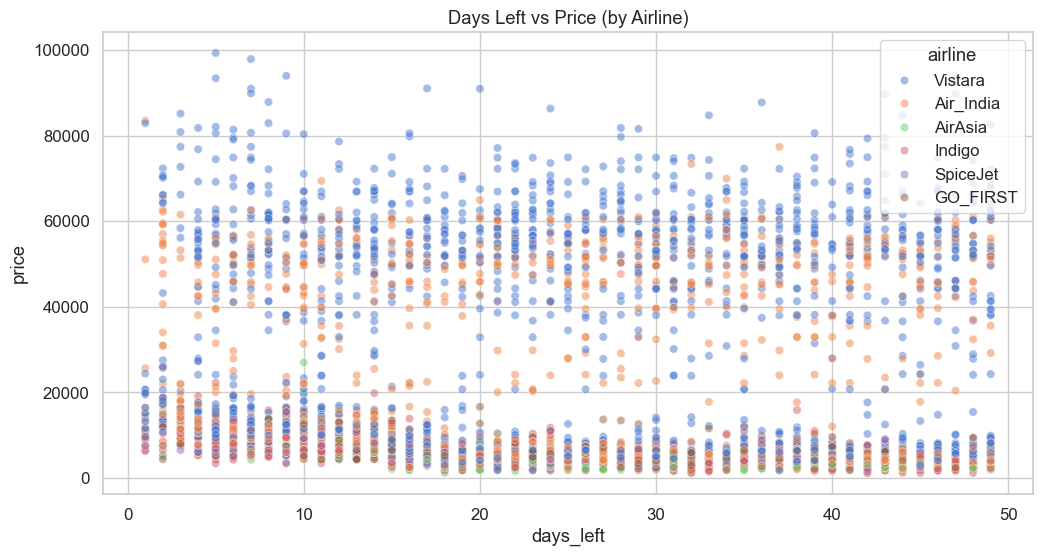

In [12]:
# Scatter: Duration vs Price by Class
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(5000), x="duration", y="price", hue="class", alpha=0.5)
plt.title("Duration vs Price (by Class)")
plt.show()

# Scatter: Days Left vs Price by Airline
plt.figure(figsize=(12,6))
sns.scatterplot(data=df.sample(5000), x="days_left", y="price", hue="airline", alpha=0.5)
plt.title("Days Left vs Price (by Airline)")
plt.show()